In [1]:
import warnings
warnings.filterwarnings(action='ignore', module='pandas')
warnings.filterwarnings(action='ignore', category=FutureWarning, module='ipykernel')
warnings.filterwarnings(action='ignore', category=FutureWarning, module='scanpy')
warnings.filterwarnings(action='ignore', category=FutureWarning, module='anndata')
warnings.filterwarnings(action='ignore', category=UserWarning, module='scanpy')

In [2]:
import os

import numpy as np
import pandas as pd

import anndata
import scanpy as sc
from sklearn.neighbors import NearestCentroid
from sklearn.metrics import normalized_mutual_info_score as nmi
from scipy.spatial.distance import cdist, pdist, squareform


import itertools
import matplotlib.pyplot as plt
import seaborn as sns
# import plotnine as p9
# import patchworklib as pw

import sys

sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
# from scLEMBAS.plotting import plot_embedding
from scLEMBAS import preprocess
from scLEMBAS import latent_separation as ls


/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm_joblib/__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [3]:
n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'Kang'

Load files:

In [4]:
tf_adata = io.read_tfad(file_name = os.path.join(data_path, 'interim', 'Kang_tf_activity.h5ad'))
tf_adata.obs.rename(columns = {'leiden': 'gene_clusters'}, inplace = True)

# adata = sc.read_h5ad(os.path.join(data_path, 'processed', 'kang_expr_scored.h5ad'))
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', 'Kang_sn_ppis.csv'), index_col = 0)

In [5]:
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'


Filter for TFs retained ni the signaling network:

In [6]:
tf_labels = tf_adata.var.index.unique().tolist()
og_n = len(tf_labels)

included_nodes = sorted(set(sn_ppis[source_label].tolist() + sn_ppis[target_label].tolist()))
tf_labels = [tf for tf in tf_labels if tf in included_nodes]
print('{} of {} TFs are present in the signaling network'.format(len(tf_labels), og_n))
tf_adata = tf_adata[:,tf_labels]


341 of 423 TFs are present in the signaling network


Embedding details:
- For PCA, we do not zero-center as is the default behavior in scanpy because TF activity is already z-scored
- We choose a resolution for Leiden clustering that maximizes the NMI with the condition, emulating the methods from [here](https://doi.org/10.1038/s41467-024-49806-9). We proceed to use this resolution for all downstream analyses.

In [7]:
file_prefix = os.path.join(data_path, 'processed', author + '_TF_activity_pca')

In [8]:
covariate_associations = ['seurat_annotations', 'stim']

In [10]:
tf_adata.obs['condition'] = tf_adata.obs.seurat_annotations.astype(str) + '^' + tf_adata.obs.stim.astype(str)

tf_adata, _, cv_df_pca_global  = ls.pc_pipeline(
    adata = tf_adata,
    pert_ids = tf_adata.obs.stim.unique(), # don't subset
    cat_ids = tf_adata.obs.seurat_annotations.unique(), # don't subset
    n_components = None, # estimate out of 50
    pert_col = 'stim',
    cat_col = 'seurat_annotations',
    get_hvgs = False, # tf activity doesn't use HVGs 
    run_umap = True,
    covariate_associations = covariate_associations, 
    per_component_association = False, 
    global_component_association = True,
    file_prefix = file_prefix,
    verbose = True,
    n_cores = n_cores,
    seed = seed,
    embkwrgs = {
        'cluster_data': True, 
        'n_neighbors': 15,
        'resolution': [0.01, 0.03, 0.1, 0.3, 1.0, 3.0],
        'cluster_col_name': 'TF_clusters',
        'nmi_label': 'condition', 
        
        'scale': False, # TF activity is z-scored
        'pcakwrgs': {
            'use_highly_variable': False, # TF activity is z-scored
            'zero_center': False # there are no HVGs so this is by default the behavior
        }    
    }
)

# tf_adata.obs.drop(columns = ['condition'], inplace = True)


The elbow was automatically identified at PC 12


''

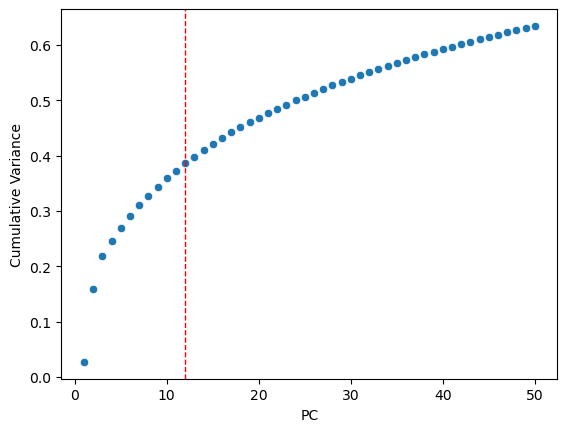

In [11]:
fig, ax = plt.subplots()
sns.scatterplot(
    y=np.cumsum(tf_adata.uns['pca']['variance_ratio']),
    x=range(1, tf_adata.uns['pca']['variance_ratio'].shape[0] + 1),
    ax=ax
)
ax.set_ylabel('Cumulative Variance')
ax.set_xlabel('PC')

n_pcs = tf_adata.uns['pca']['pca_rank']
ax.axvline(x=n_pcs, color='red', linestyle='--', linewidth=1)

print('The elbow was automatically identified at PC {}'.format(n_pcs))
;

In [13]:
comparison_metric = 'chance_adjusted_accuracy'

In [21]:
tf_adata.obs.head()

,orig.ident,nCount_RNA,nFeature_RNA,stim,seurat_annotations,n_genes,gene_clusters,condition,TF_clusters
AAACATACATTTCC.1,IMMUNE_CTRL,3017,877,CTRL,CD14 Mono,877,0,CD14 Mono^CTRL,1
AAACATACCAGAAA.1,IMMUNE_CTRL,2481,713,CTRL,CD14 Mono,713,1,CD14 Mono^CTRL,1
AAACATACCTCGCT.1,IMMUNE_CTRL,3420,850,CTRL,CD14 Mono,850,5,CD14 Mono^CTRL,1
AAACATACCTGGTA.1,IMMUNE_CTRL,3156,1109,CTRL,pDC,1109,6,pDC^CTRL,3
AAACATACGATGAA.1,IMMUNE_CTRL,1868,634,CTRL,CD4 Memory T,634,7,CD4 Memory T^CTRL,0


In [23]:
viz_df.covariate.unique()

['Seurat Annotations', 'Stim']
Categories (2, object): ['Stim' < 'Seurat Annotations']

0            NaN
1            NaN
2            NaN
3            NaN
4            NaN
5    Stimulation
6    Stimulation
7    Stimulation
8    Stimulation
9    Stimulation
Name: covariate, dtype: object

''

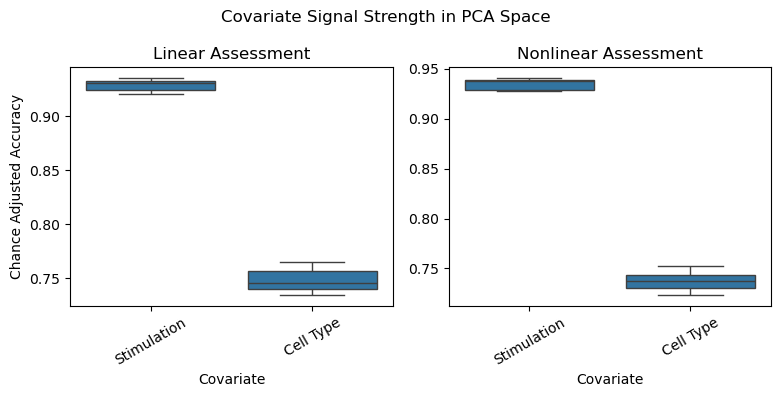

In [28]:
cv_global = cv_df_pca_global
fig, ax = plt.subplots(ncols = 2, nrows = 1, figsize = (8, 4))


for j, model_type in enumerate(cv_global.model_type.unique()):
    viz_df = cv_global[cv_global.model_type == model_type]
    viz_df = viz_df[['fold', 'model_type'] + [col for col in viz_df.columns if col.endswith(comparison_metric)]]
    viz_df.columns = [col if not col.endswith(comparison_metric) else col.split(comparison_metric)[0] for col in viz_df.columns]
    viz_df = viz_df.drop(columns = ['model_type']).melt(id_vars = 'fold', var_name = 'covariate', value_name = 'score')
    x_order = viz_df.groupby('covariate')['score'].median().sort_values(ascending = False).index.tolist()
    viz_df.covariate = pd.Categorical(viz_df.covariate, ordered = True, categories = x_order)
    viz_df.covariate = viz_df.covariate.apply(lambda x: ' '.join([x_.capitalize() for x_ in x[:-1].split('_')]))

    viz_df.covariate = viz_df.covariate.map({'Stim': 'Stimulation', 'Seurat Annotations': 'Cell Type'})
    
    
    sns.boxplot(data = viz_df, x = 'covariate', y = 'score', ax = ax[j])
    for label in ax[j].get_xticklabels():
        label.set_rotation(30)


    ax[j].set_xlabel('Covariate')
    ax[j].set_ylabel('Chance Adjusted Accuracy') if j == 0 else ax[j].set_ylabel('')
    ax[j].set_title(model_type.capitalize() + ' Assessment') #if i == 0 else ax[j].set_title('')

fig.suptitle('Covariate Signal Strength in PCA Space')
fig.tight_layout()

fig.savefig(os.path.join(data_path, 'figures', author + '_TF_pca_quantification.png'), 
        dpi=300, bbox_inches="tight")

;

In [29]:
cat_cov = ['gene_clusters', 'TF_clusters', 'seurat_annotations', 'stim']
NMI_df = pd.DataFrame(columns = ['NMI'], 
                      index = ['^'.join(comb) for comb in itertools.combinations(cat_cov, 2)])
for comb in NMI_df.index:
    NMI_df.loc[comb, 'NMI'] = nmi(tf_adata.obs[comb.split('^')[0]], tf_adata.obs[comb.split('^')[1]])
    
NMI_df

,NMI
gene_clusters^TF_clusters,0.471775
gene_clusters^seurat_annotations,0.45822
gene_clusters^stim,0.287358
TF_clusters^seurat_annotations,0.513341
TF_clusters^stim,0.248675
seurat_annotations^stim,0.003175


We will use components 2 and 3 for visualization of PC space, accordingly.

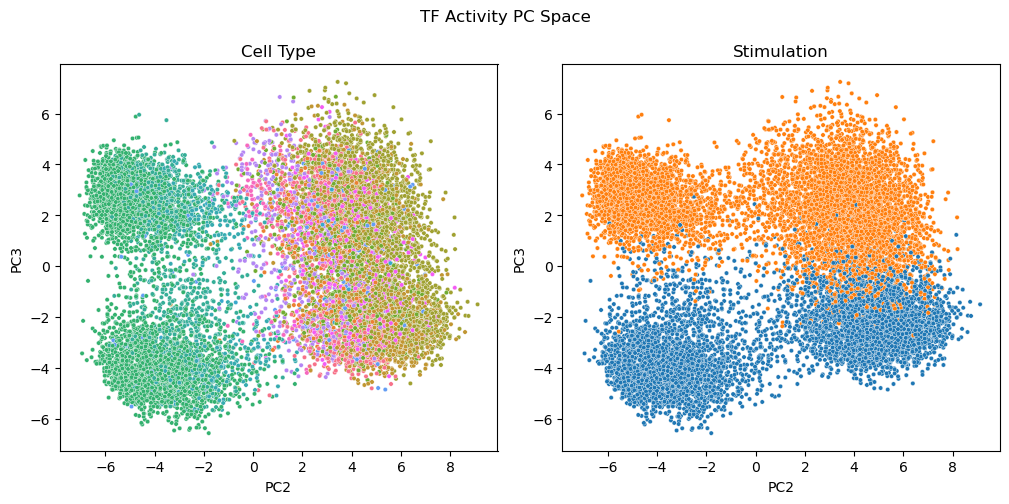

In [30]:
ls.visualize_latent_space(
    adata = tf_adata, 
    latent_label = 'pca', 
    covariates = ['seurat_annotations', 'stim'],
    panel_titles = ['Cell Type', 'Stimulation'],
    components = [2, 3], 
    n_frac = 1, 
    frac_col = None, 
    fig_title = 'TF Activity PC Space', 
    legend = False, 
    seed = 888, 
    file_name = file_prefix + '_space.png'
)

## PCA side-note

Note on PC1. PC1 is capturing mean TF activity. While we chose not to zero-center due to these being 'consensus' scores, there is still a bias in the activity distribution: 

In [32]:
print(f"Mean TF activity: {tf_adata.X.mean():.4f}")
print(f"Median TF activity: {np.median(tf_adata.X):.4f}")
print(f"Proportion of positive scores: {(tf_adata.X > 0).mean():.4f}")

Mean TF activity: 0.0908
Median TF activity: 0.0570
Proportion of positive scores: 0.5365


These statistics show that decoupler's consensus TF activities have a systematic positive shift - the mean is positive (0.09), median is positive (0.06), and 54% of values are positive. Thus, **PC1 is going to capture this shift (in other words, the mean)** (which could be due to e.g., net positive TF activity or some sort of background shift). 

Biologically, PC1 likely represents one or more of the following::
- Global transcriptional activity state - cells with generally higher TF activity across the board
- Technical variation - cells with better capture/sequencing might show higher activities
- Cell state - metabolically active vs. quiescent cells


Let's see the correlation between PC1 and the mean:

In [33]:
import scipy
pr = scipy.stats.pearsonr(tf_adata.obsm['X_pca'][:, 0], tf_adata.X.mean(axis=1)).statistic
print('Pearson correlation between PC1 and data mean: {:.2f}'.format(pr))

Pearson correlation between PC1 and data mean: 0.77


Furthermore, we can see that with zero-centering, PC1 is removed, and instead PC2 and PC3 become PC1 and PC2:

In [34]:
ta_zc = tf_adata.copy()
sc.tl.pca(ta_zc, zero_center = True)

pr = scipy.stats.pearsonr(ta_zc.obsm['X_pca'][:, 0], tf_adata.obsm['X_pca'][:, 1]).statistic
print('Pearson correlation between zero-centered PC1 and non-zero-centered PC2: {:.2f}'.format(pr))
pr = scipy.stats.pearsonr(ta_zc.obsm['X_pca'][:, 1], tf_adata.obsm['X_pca'][:, 2]).statistic
print('Pearson correlation between zero-centered PC2 and non-zero-centered PC3: {:.2f}'.format(pr))

Pearson correlation between zero-centered PC1 and non-zero-centered PC2: 1.00
Pearson correlation between zero-centered PC2 and non-zero-centered PC3: 1.00


Because 1) this information is retained in the decomposition, 2) conesnsus scores are input to the PCA, and 3) PC1 without zero-centering still represents some information (either global TF activity state or technical covariance), we proceed without zero-centering

In [89]:
# stats_adata = tf_adata.copy()
# stats_adata.uns['pca']['pca_rank'] = 3

# r2_df = ls.latent_association(
#     adata = stats_adata, 
#     covariates = ['nCount_RNA', 'seurat_annotations', 'stim'], 
#     model_type = 'linear', 
#     n_cores = n_cores, 
#     latent_label = 'pca', 
#     seed = 888
# )

# r2_df.drop('model_type', axis=1).pivot_table(
#     columns='PC', 
#     values=['nCount_RNA', 'seurat_annotations', 'stim']
# )

End Side-Note

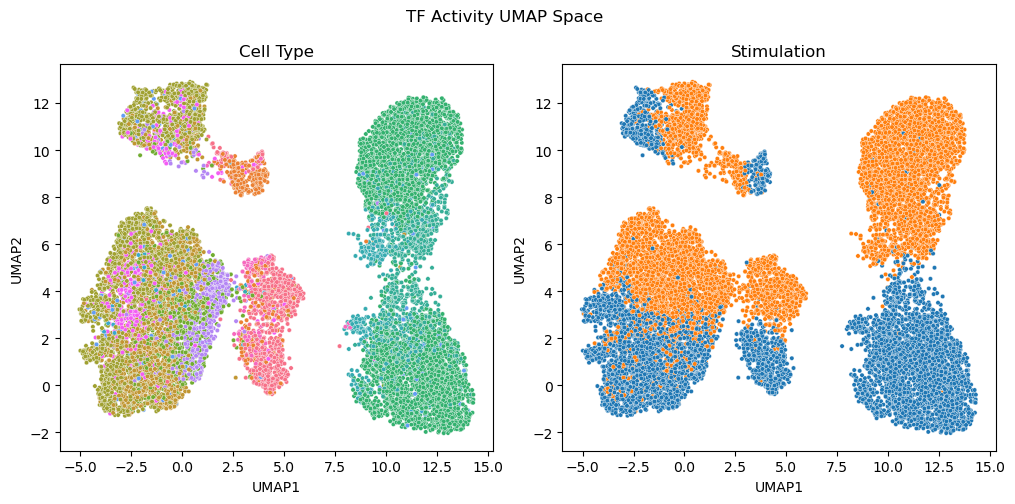

In [36]:
ls.visualize_latent_space(
    adata = tf_adata, 
    latent_label = 'umap', 
    covariates = ['seurat_annotations', 'stim'],
    panel_titles = ['Cell Type', 'Stimulation'],
    components = [1,2], 
    n_frac = 1, 
    frac_col = None, 
    fig_title = 'TF Activity UMAP Space', 
    legend = False, 
    seed = 888, 
    file_name = file_prefix + '_umap_space.png'
)

In [37]:
io.write_tfad(tf_adata, os.path.join(data_path, 'processed', 'Kang_tf_activity.h5ad'))